# Exploratory Data Analysis (EDA)
In this notebook, we explore the intent and sentiment datasets.


## 1. Import Libraries
Let's load the necessary tools for data manipulation and visualization.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

## 2. Load Datasets
We will read the processed data from our data directory.
*Note: Make sure you have run `src/pipeline/prepare_data.py` first.*


In [2]:
try:
    intent_df = pd.read_csv('../data/processed/custom_intents.csv')
    sentiment_df = pd.read_csv('../data/processed/wisesight_sentiment.csv')
    print("Datasets loaded successfully!")
except FileNotFoundError:
    print("Error: Processed data not found. Please run the data preparation pipeline first.")

Datasets loaded successfully!


## 3. Intent Dataset Exploration
Let's check the structure, missing values, and a brief summary of the custom intent dataset.


In [3]:
display(intent_df.head())
print("\n--- Dataset Info ---")
print(intent_df.info())
print("\n--- Missing Values ---")
print(intent_df.isnull().sum())
print("\n--- Unique Labels ---")
print(intent_df['label'].unique())

,text,label
0,บอดชัดเลยซื้อมาแกะกล่องปุ๊บจอเป็นเส้นเลย ทำไมไ...,Product Defect
1,ของขาดส่ง บอกว่าจะส่งเพิ่มแต่เงียบ ขอคืนส่วนที...,Refund Request
2,แพ็กกิ้งห่วยแตกมากเลยครับ กล่องพังของข้างในแตก...,Delivery Issue
3,ซื้อมาแล้วเจอของมีตำหนิไม่รู้จะทำไงดี,Product Defect
4,ร้านนี้แย่ ขนส่งก็แย่ สมควรโดนตำหนิ,Delivery Issue



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1253 non-null   object
 1   label   1253 non-null   object
dtypes: object(2)
memory usage: 19.7+ KB
None

--- Missing Values ---
text     0
label    0
dtype: int64

--- Unique Labels ---
['Product Defect' 'Refund Request' 'Delivery Issue' 'Product Question']


### Intent Label Distribution


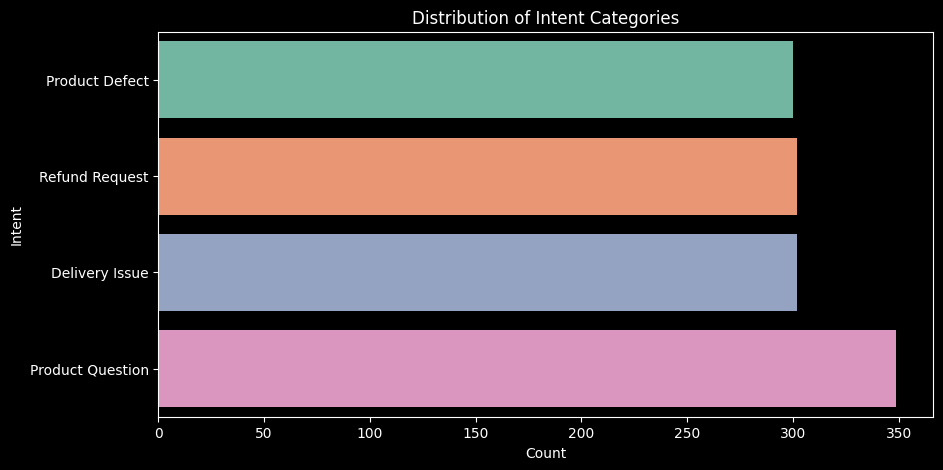

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(data=intent_df, y='label', palette='Set2')
plt.title('Distribution of Intent Categories')
plt.xlabel('Count')
plt.ylabel('Intent')
plt.show()

## 4. Sentiment Dataset Exploration
Now we'll do the same checks for the Wisesight sentiment dataset.


In [5]:
display(sentiment_df.head())
print("\n--- Dataset Info ---")
print(sentiment_df.info())
print("\n--- Missing Values ---")
print(sentiment_df.isnull().sum())
print("\n--- Unique Labels ---")
print(sentiment_df['category'].unique())

,texts,category
0,ไปจองมาแล้วนาจา Mitsubishi Attrage ได้หลังสงกร...,1
1,เปิดศักราชใหม่! นายกฯ แถลงข่าวก่อนการแข่งขันศึ...,1
2,บัตรสมาชิกลดได้อีกไหมคับ,1
3,สนใจ new mazda2ครับ,1
4,😍😍,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26121 entries, 0 to 26120
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   texts     26121 non-null  object
 1   category  26121 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 408.3+ KB
None

--- Missing Values ---
texts       0
category    0
dtype: int64

--- Unique Labels ---
[1 0 2]


### Sentiment Label Distribution


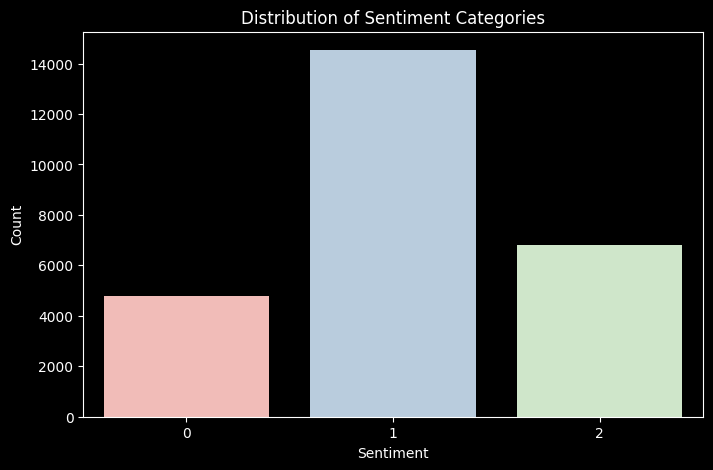

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=sentiment_df, x='category', palette='Pastel1')
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## 5. Text Length Analysis
Understanding the length of our input text helps us decide on tokenization `max_length`.


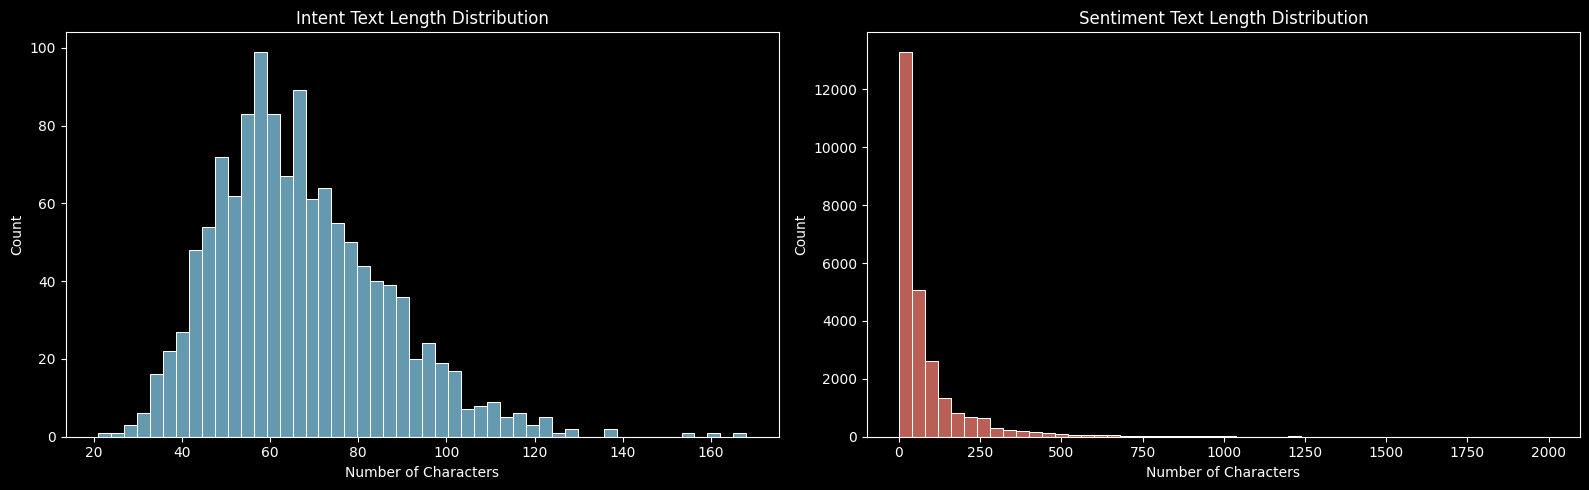

Intent Text Length Stats:
count    1253.000000
mean       66.968077
std        19.205853
min        21.000000
25%        54.000000
50%        65.000000
75%        78.000000
max       168.000000
Name: text_len, dtype: float64

Sentiment Text Length Stats:
count    26121.000000
mean        89.329275
std        146.723391
min          1.000000
25%         19.000000
50%         39.000000
75%         98.000000
max       1997.000000
Name: text_len, dtype: float64


In [7]:
intent_df['text_len'] = intent_df['text'].astype(str).apply(len)
sentiment_df['text_len'] = sentiment_df['texts'].astype(str).apply(len)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(intent_df['text_len'], bins=50, ax=ax[0], color='skyblue')
ax[0].set_title('Intent Text Length Distribution')
ax[0].set_xlabel('Number of Characters')

sns.histplot(sentiment_df['text_len'], bins=50, ax=ax[1], color='salmon')
ax[1].set_title('Sentiment Text Length Distribution')
ax[1].set_xlabel('Number of Characters')

plt.tight_layout()
plt.show()

print("Intent Text Length Stats:")
print(intent_df['text_len'].describe())
print("\nSentiment Text Length Stats:")
print(sentiment_df['text_len'].describe())